# Experiment No. 9

## Title
**To implement Bezier Curve Generation using control points**

## Objective
To generate a smooth curve using Bezier curve formulation and observe how control points influence the shape of the curve.

## Theory
A Bezier curve is a parametric curve widely used in computer graphics for modeling smooth curves. It is defined using a set of control points.

For a cubic Bezier curve (4 control points), the equation is:

$$
B(t) = (1 - t)^3 P_0 + 3t(1 - t)^2 P_1 + 3t^2(1 - t) P_2 + t^3 P_3
$$

where:
- $0 \leq t \leq 1$
- $P_0, P_1, P_2, P_3$ are control points

General form (n-th degree Bezier curve):

$$
B(t) = \sum_{i=0}^{n} \binom{n}{i} (1 - t)^{n-i} t^i P_i
$$

Bezier curves have the following properties:
- The curve starts at $P_0$ and ends at $P_n$
- The curve lies within the convex hull of control points
- The shape is influenced by intermediate control points

## Procedure
1. Define a set of control points.
2. Choose a parameter $t$ varying from 0 to 1.
3. Compute the Bezier curve using the Bernstein polynomial formula.
4. Generate multiple points along the curve.
5. Plot the control polygon and the Bezier curve.
6. Save the output image.

## Output
- Control points and control polygon
- Smooth Bezier curve
- Output image saved as `Exp9_Output.png`

## Result and Discussion
The Bezier curve was successfully generated using the given control points. The curve smoothly interpolates between the first and last control points while being influenced by intermediate points. The result demonstrates how control points shape the curve without necessarily lying on it.

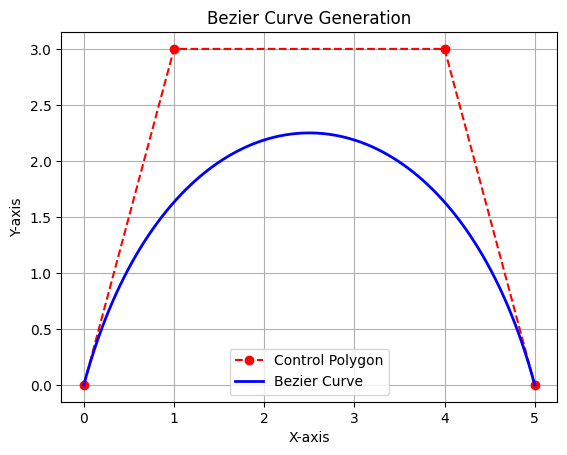

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

def bezier_curve(control_points, num_points=100):
    n = len(control_points) - 1
    t_values = np.linspace(0, 1, num_points)

    curve_points = []

    for t in t_values:
        point = np.zeros(2)
        for i in range(n + 1):
            bernstein = comb(n, i) * (t ** i) * ((1 - t) ** (n - i))
            point += bernstein * control_points[i]
        curve_points.append(point)

    return np.array(curve_points)

# Define control points
control_points = np.array([
    [0, 0],
    [1, 3],
    [4, 3],
    [5, 0]
])

curve = bezier_curve(control_points)

# Plot
plt.plot(control_points[:, 0], control_points[:, 1], 'ro--', label="Control Polygon")
plt.plot(curve[:, 0], curve[:, 1], 'b', linewidth=2, label="Bezier Curve")

plt.title("Bezier Curve Generation")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.savefig("Exp9_Output.png")
plt.show()